### Imports

In [1]:
import pandas as pd
import numpy as np
import re
import pickle
import os
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error


### Dataset Load

In [2]:
# ---------------- 1️⃣ Load Dataset ----------------
df = pd.read_json("data.jsonl", lines=True)

# Fill missing text fields
text_cols = ['title', 'description', 'input_description', 'output_description']
df[text_cols] = df[text_cols].fillna("")

# Display first few rows
df.head()


,title,description,input_description,output_description,sample_io,problem_class,problem_score,url
0,Uuu,Unununium (Uuu) was the name of the chemical\n...,The input consists of one line with two intege...,The output consists of $M$ lines where the $i$...,"[{'input': '7 10', 'output': '1 2 2 3 1 3 3 4 ...",hard,9.7,https://open.kattis.com/problems/uuu
1,House Building,A number of eccentrics from central New York h...,"The input consists of $10$ test cases, which a...",Print $K$ lines with\n the positions of the...,"[{'input': '0 2 3 2 50 60 50 30 50 40', 'outpu...",hard,9.7,https://open.kattis.com/problems/husbygge
2,Mario or Luigi,Mario and Luigi are playing a game where they ...,,,"[{'input': '', 'output': ''}]",hard,9.6,https://open.kattis.com/problems/marioorluigi
3,The Wire Ghost,Žofka is bending a copper wire. She starts wit...,The first line contains two integers $L$ and $...,The output consists of a single line consistin...,"[{'input': '4 3 3 C 2 C 1 C', 'output': 'GHOST...",hard,9.6,https://open.kattis.com/problems/thewireghost
4,Barking Up The Wrong Tree,"Your dog Spot is let loose in the park. Well, ...",The first line of input consists of two intege...,Write a single line containing the length need...,"[{'input': '2 0 10 0 10 10', 'output': '14.14'...",hard,9.6,https://open.kattis.com/problems/barktree


### Text Preprocessing

In [3]:
# Combine all text fields
df['full_text'] = df['title'] + " " + df['description'] + " " + df['input_description'] + " " + df['output_description']

# Clean text: lowercase + remove unwanted chars but keep math symbols
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s\+\-\*\=<>]", " ", text)  # Keep math symbols
    return text

df['full_text'] = df['full_text'].apply(clean_text)


### Feature Engineering

In [4]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_text = tfidf.fit_transform(df['full_text'])

# Additional numeric features
def count_math_symbols(text):
    return sum(text.count(sym) for sym in ["+", "-", "*", "/", "=", "<", ">"])

df['text_length'] = df['full_text'].apply(len)
df['math_symbols'] = df['full_text'].apply(count_math_symbols)


### Train-Test Split

In [5]:
# Targets
y_class = df['problem_class']  # classification
y_score = df['problem_score']  # regression

# Train-test split
X_train, X_test, y_class_train, y_class_test, y_score_train, y_score_test = train_test_split(
    X_text, y_class, y_score, test_size=0.2, random_state=42
)


### Classification Model

In [6]:
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_class_train)

y_pred_class = clf.predict(X_test)

print("Classification Accuracy:", accuracy_score(y_class_test, y_pred_class))
print("Confusion Matrix:\n", confusion_matrix(y_class_test, y_pred_class))
print(classification_report(y_class_test, y_pred_class))


Classification Accuracy: 0.5309842041312273
Confusion Matrix:
 [[ 18  80  38]
 [  6 374  45]
 [  6 211  45]]
              precision    recall  f1-score   support

        easy       0.60      0.13      0.22       136
        hard       0.56      0.88      0.69       425
      medium       0.35      0.17      0.23       262

    accuracy                           0.53       823
   macro avg       0.50      0.39      0.38       823
weighted avg       0.50      0.53      0.46       823



### Regression Model

In [7]:
reg = RandomForestRegressor(n_estimators=200, random_state=42)
reg.fit(X_train, y_score_train)

y_pred_score = reg.predict(X_test)

mae = mean_absolute_error(y_score_test, y_pred_score)
rmse = np.sqrt(mean_squared_error(y_score_test, y_pred_score))
print("Regression MAE:", mae, "RMSE:", rmse)


Regression MAE: 1.7080285540704738 RMSE: 2.029778411865645


### Plots

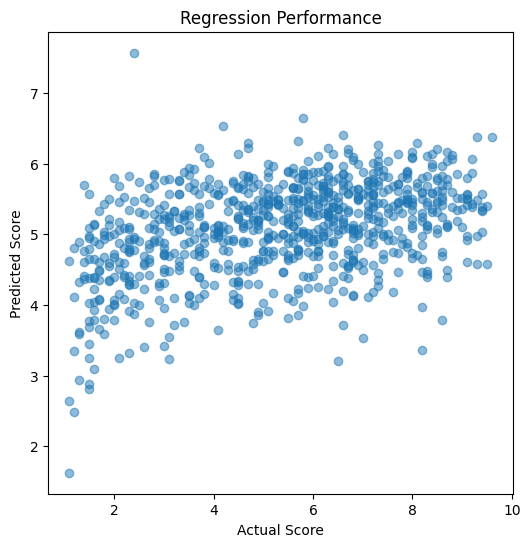

In [8]:
# Scatter plot to visualize regression
plt.figure(figsize=(6,6))
plt.scatter(y_score_test, y_pred_score, alpha=0.5)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Regression Performance")
plt.show()

### Save Models

In [9]:
# Create models folder if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save TF-IDF vectorizer
with open("models/tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)

# Save classification model
with open("models/classifier.pkl", "wb") as f:
    pickle.dump(clf, f)

# Save regression model
with open("models/regressor.pkl", "wb") as f:
    pickle.dump(reg, f)

print("✅ All models saved successfully")


✅ All models saved successfully
